In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv("/kaggle/input/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv")

In [3]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


# EDA Visualization

In [4]:
sns.set_style('whitegrid')
df['Disruption_Occurred'].value_counts()

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Weather_Condition'>

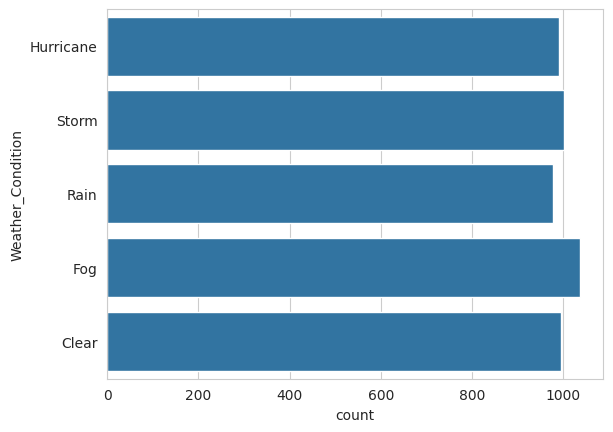

In [5]:
sns.countplot(df['Weather_Condition'])

<Axes: xlabel='count', ylabel='Origin_Port'>

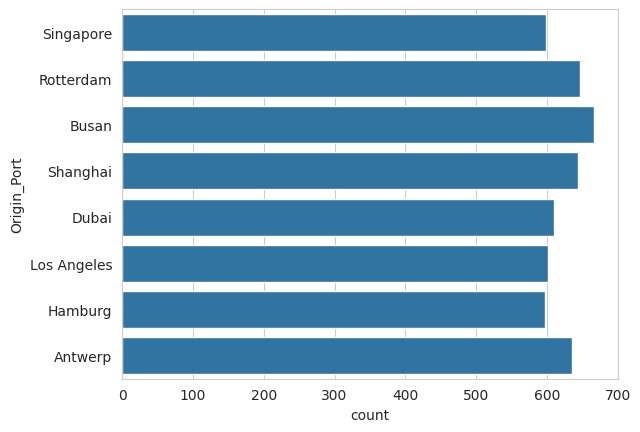

In [6]:
sns.countplot(df['Origin_Port'])

<Axes: xlabel='count', ylabel='Destination_Port'>

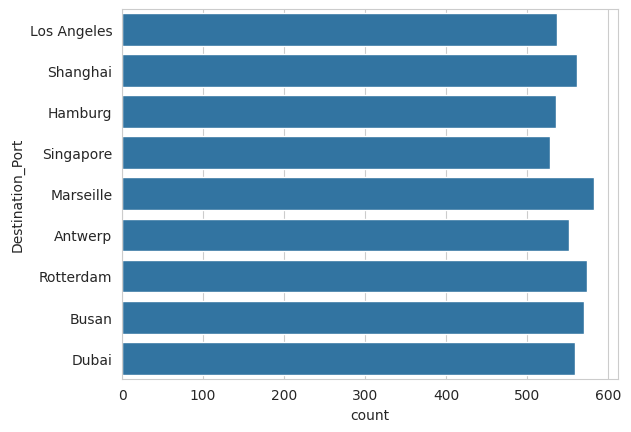

In [7]:
sns.countplot(df['Destination_Port'])

(array([1185.,    0.,    0., 1320.,    0.,    0., 1214.,    0.,    0.,
        1281.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

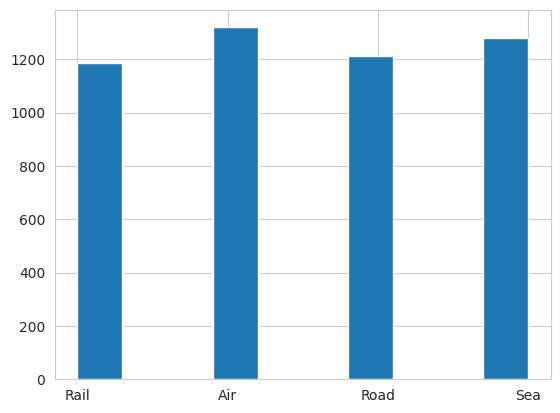

In [8]:
plt.hist(df['Transport_Mode'])

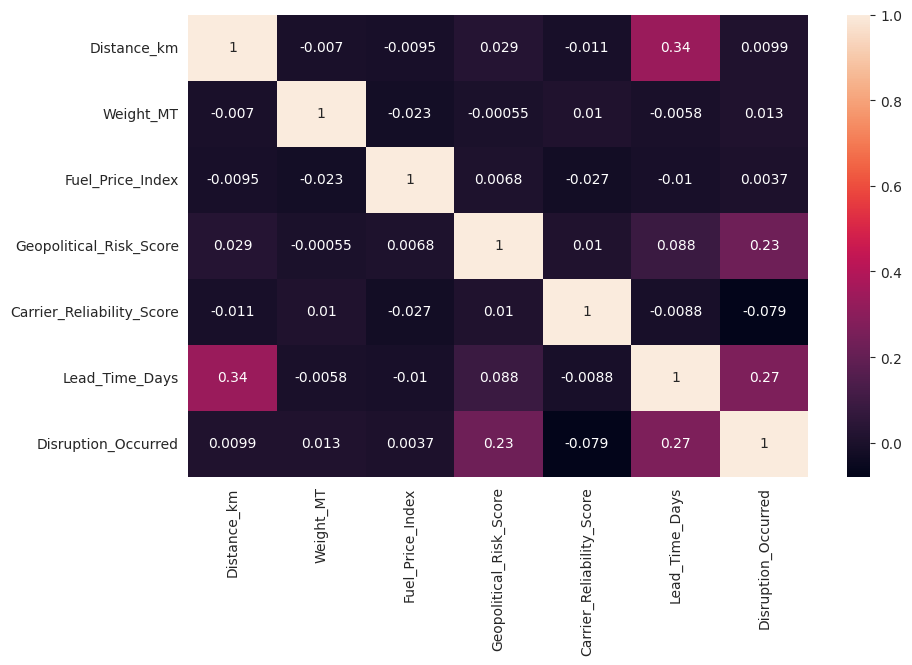

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='Product_Category', ylabel='Count'>

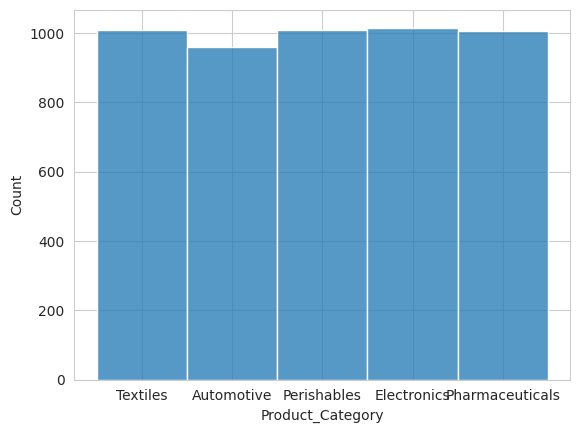

In [10]:
sns.histplot(df['Product_Category'])

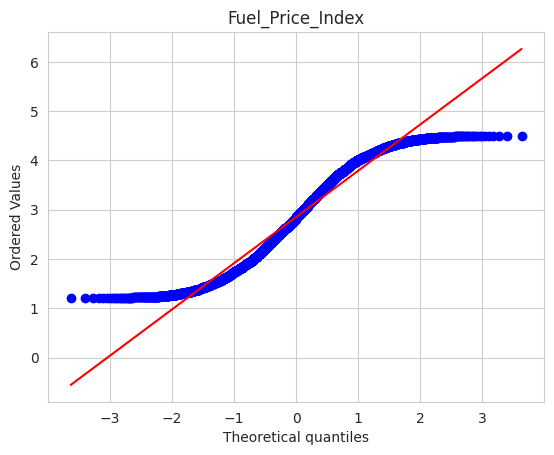

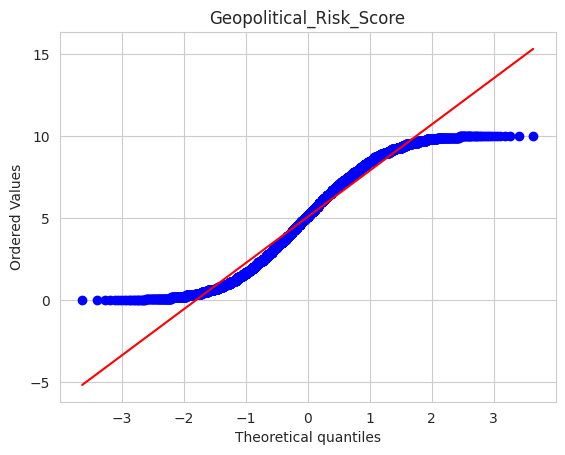

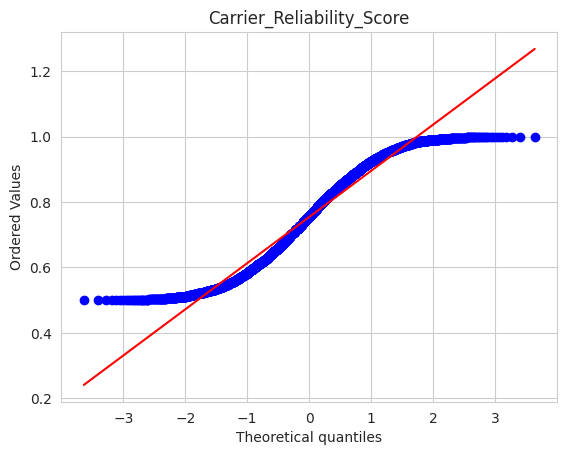

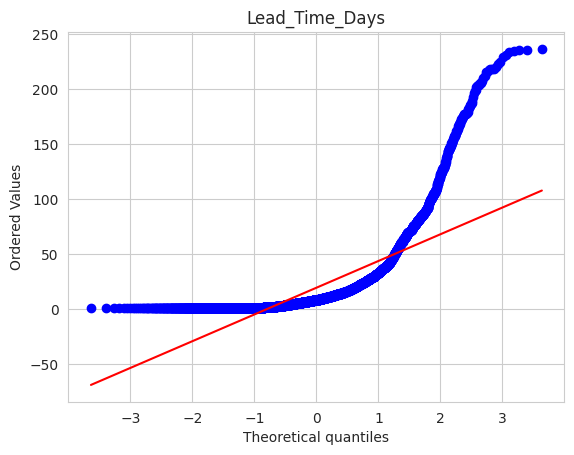

In [11]:
l1 = ['Fuel_Price_Index','Geopolitical_Risk_Score','Carrier_Reliability_Score','Lead_Time_Days']

for pt in l1:
    stats.probplot(df[pt], dist="norm", plot=plt)
    plt.title(pt)
    plt.show()

# Improving Data for Training

((array([-3.63568806, -3.40036853, -3.27067228, ...,  3.27067228,
          3.40036853,  3.63568806]),
  array([-1.55923488, -1.55923488, -1.55923488, ...,  2.28900439,
          2.28971217,  2.29139234])),
 (np.float64(0.9828678174271834),
  np.float64(-4.4695653624657254e-17),
  np.float64(0.9822120803395167)))

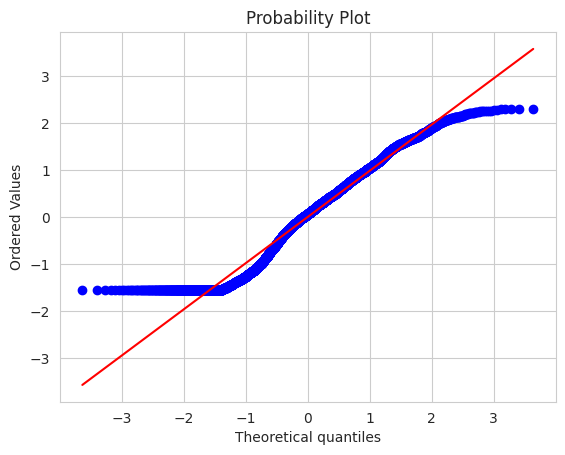

In [12]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['Lead_Time_Days'] = pt.fit_transform(df[['Lead_Time_Days']])

stats.probplot(df['Lead_Time_Days'], dist="norm", plot=plt)

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output = False)

In [14]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,1.202188,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,1.194482,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,0.305092,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,1.368923,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,-1.559235,1


In [15]:
df['Weather_Condition'] = pd.DataFrame(le.fit_transform(df['Weather_Condition']))

In [16]:
Transport_Mode_trans = pd.DataFrame(ohe.fit_transform(df[['Origin_Port']]),columns= ohe.get_feature_names_out(["Origin_Port"]))
Destination_Port_trans = pd.DataFrame(ohe.fit_transform(df[['Destination_Port']]),columns= ohe.get_feature_names_out(["Destination_Port"]))
Transport_Mode_trans = pd.DataFrame(ohe.fit_transform(df[['Transport_Mode']]),columns= ohe.get_feature_names_out(["Transport_Mode"]))
Product_Category_trans = pd.DataFrame(ohe.fit_transform(df[['Product_Category']]),columns= ohe.get_feature_names_out(["Product_Category"]))

In [17]:
df =pd.concat([df,Transport_Mode_trans,Destination_Port_trans,Transport_Mode_trans,Product_Category_trans],axis= 1)

In [18]:
df.drop(['Shipment_ID','Origin_Port','Destination_Port','Transport_Mode','Product_Category'],axis = 1 ,inplace = True)

In [19]:
df.head()

,Date,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Transport_Mode_Air,...,Destination_Port_Singapore,Transport_Mode_Air,Transport_Mode_Rail,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Automotive,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles
0,2025-10-16,5930.83,197.42,2.43,5.0,2,0.865,1.202188,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2024-04-24,14285.36,237.24,2.30,7.5,4,0.592,1.194482,1,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2024-01-26,11113.91,427.42,1.78,5.6,3,0.673,0.305092,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2024-10-08,9180.55,170.66,3.20,0.8,2,0.832,1.368923,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2024-09-07,2762.27,434.96,2.77,1.9,1,0.741,-1.559235,1,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Extracting "Year" from Date

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df.drop(['Date'],axis = 1,inplace = True)
df['year'].value_counts()

year
2025    2545
2024    2455
Name: count, dtype: int64

In [21]:
df.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Transport_Mode_Air,Transport_Mode_Rail,...,Transport_Mode_Air,Transport_Mode_Rail,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Automotive,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,year
0,5930.83,197.42,2.43,5.0,2,0.865,1.202188,1,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2025
1,14285.36,237.24,2.30,7.5,4,0.592,1.194482,1,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2024
2,11113.91,427.42,1.78,5.6,3,0.673,0.305092,0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2024
3,9180.55,170.66,3.20,0.8,2,0.832,1.368923,1,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2024
4,2762.27,434.96,2.77,1.9,1,0.741,-1.559235,1,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2024


# Splitting Inputs and Outputs

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X = df.drop(['Disruption_Occurred'],axis = 1)
y = df['Disruption_Occurred']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

# Using Neural Networks

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(set(y))

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')
    
])

2026-02-25 15:47:42.981624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772034463.173538      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772034463.231974      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772034463.663782      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772034463.663824      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772034463.663826      24 computation_placer.cc:177] computation placer alr

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,370 (56.13 KB)

 Trainable params: 14,370 (56.13 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    batch_size=512
)

Epoch 1/100


I0000 00:00:1772034488.520738      72 service.cc:152] XLA service 0x7ae46800acd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772034488.520775      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772034488.520781      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772034488.823784      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5527 - loss: 0.7127

I0000 00:00:1772034490.709440      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 422ms/step - accuracy: 0.5515 - loss: 0.7068 - val_accuracy: 0.5975 - val_loss: 0.6687
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6064 - loss: 0.6678 - val_accuracy: 0.6237 - val_loss: 0.6493
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6113 - loss: 0.6587 - val_accuracy: 0.6350 - val_loss: 0.6395
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6226 - loss: 0.6431 - val_accuracy: 0.6413 - val_loss: 0.6305
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6369 - loss: 0.6290 - val_accuracy: 0.6538 - val_loss: 0.6210
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6498 - loss: 0.6268 - val_accuracy: 0.6687 - val_loss: 0.6118
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6482 - loss: 0.6191 - val_accuracy: 0.6762 - val_loss: 0.6044
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6685 - loss: 0.6035 - val_accuracy: 0.6888 - val_loss: 0.5988
Epo

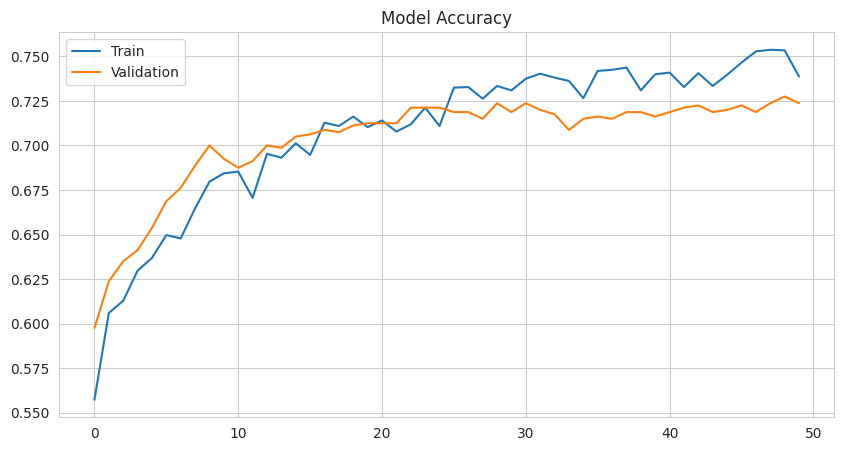

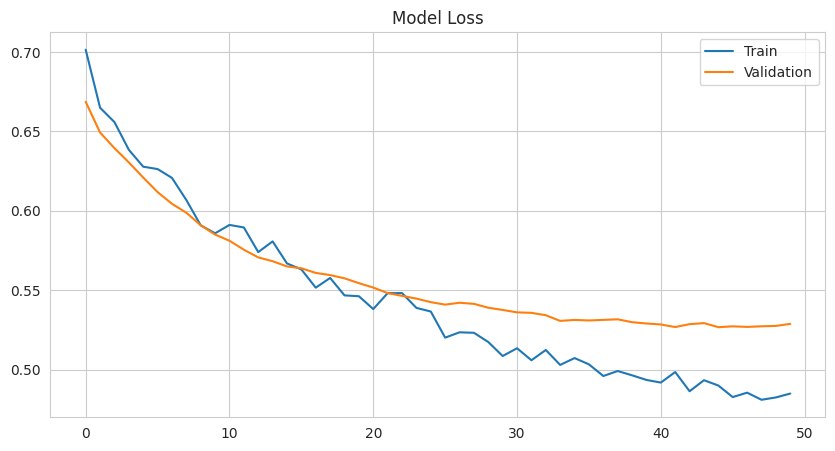

In [28]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

In [29]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score,f1_score,confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)


print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7462 - loss: 0.4817
Test Accuracy: 0.7350000143051147
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.64      0.70      0.67       379
           1       0.81      0.75      0.78       621

    accuracy                           0.73      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.74      0.73      0.74      1000

Accuracy: 0.735
